In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.trading_strategy import compute_spread, compute_rolling_z, generate_signals
from src.pair_selection import find_correlated_pairs, find_cointegrated_pairs
import src.backtest as bt

## Load the Processed Price Dataset

In [2]:
adj_close_df = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)

## Compute Cointegrated Pairs

- Rank them in order of smallest to highest p value.
- Then backtest using the best pair (smallest p value) first before doing it on multiple pairs.

In [3]:
correlated_pairs = find_correlated_pairs(adj_close_df, 0.7)
cointegrated_pairs = find_cointegrated_pairs(adj_close_df, correlated_pairs, 0.05)
cointegrated_pairs.sort(key = lambda x: x[3])

In [4]:
first_pair = cointegrated_pairs[0]
print(first_pair)

('JBLU', 'LUV', np.float64(0.9504446769104575), np.float64(7.109656764761808e-05))


In [5]:
first_pair_alpha, first_pair_beta, first_pair_spread = compute_spread(adj_close_df, first_pair)
first_pair_rolling_z = compute_rolling_z(first_pair_spread, 60)
first_pair_signals = generate_signals(first_pair_rolling_z)
print(first_pair_signals)

Date
2017-01-03    0
2017-01-04    0
2017-01-05    0
2017-01-06    0
2017-01-09    0
             ..
2024-12-24    0
2024-12-26    0
2024-12-27    0
2024-12-30    0
2024-12-31    0
Length: 2012, dtype: int64


## Position Sizing

- To translate our directional signals into an actual trade, we size each position to be beta-neutral: the dollar amount allocated to each stock reflects the hedge ratio (beta) from our regression, so that price movements in one stock are proportionally offset by the other. 
- This isolates the strategy's returns to the spread's mean-reversion rather than general market movement.

## Calculating Daily PnL

- For each day we hold a position, profit/loss is calculated from the price change in each stock multiplied by the number of shares held (fixed at entry), with direction determined by the signal (long or short the spread). 
- Days with no position have zero PnL. Summing daily PnL over time gives our cumulative equity curve.

In [6]:
capital = 10000
trade_cost_rate = 0.001
daily_pnl = bt.calculate_daily_pnl(adj_close_df, capital, trade_cost_rate, first_pair, first_pair_signals, first_pair_beta) 
print(daily_pnl)

Date
2017-01-03    0.0
2017-01-04    0.0
2017-01-05    0.0
2017-01-06    0.0
2017-01-09    0.0
             ... 
2024-12-24    0.0
2024-12-26    0.0
2024-12-27    0.0
2024-12-30    0.0
2024-12-31    0.0
Length: 2012, dtype: float64


## Equity Curve

Plotting cumulative PnL over time shows the strategy's overall performance. Despite periods of drawdown, the strategy shows an overall upward trend in profitability across the ~8 year backtest period.

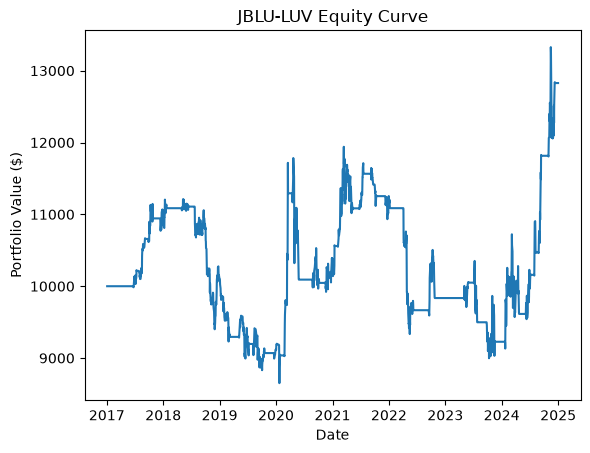

In [14]:
daily_pnl_cumsum = daily_pnl.cumsum()
bt.plot_equity_curve(capital, first_pair, daily_pnl_cumsum, True)     

## Sharpe Ratio

The Sharpe ratio measures risk-adjusted return: average return per unit of volatility taken, nnualized using sqrt(252) trading days. Our strategy achieves a Sharpe of approximately 0.30, which is relatively
low (a Sharpe above 1 is generally considered decent). This likely reflects the strategy's basic entry/exit thresholds, lack of transaction cost modeling, and reliance on a single pair rather than a diversified portfolio of pairs — all areas for potential refinement.

In [8]:
sharpe = bt.calculate_sharpe(capital, daily_pnl)
print(sharpe)

0.23937743901841346


## Maximum Drawdown

Maximum drawdown measures the largest peak-to-trough decline in the equity curve, capturing the worst-case loss an investor would have experienced. Our strategy has a max drawdown of approximately $2766, against a starting capital of $10,000 — a meaningful risk to consider alongside the modest Sharpe ratio.

In [9]:
max_drawdown = bt.calculate_max_drawdown(daily_pnl_cumsum)
print(max_drawdown)    

2943.0744365533155


## CAGR (Compound Annual Growth Rate)

CAGR represents the annualized rate of return over the backtest period. Our strategy achieved a CAGR of approximately 3.9%, a modest return consistent with the low Sharpe ratio — suggesting there's room for improvement through refined entry/exit thresholds, transaction cost modeling, or trading a diversified portfolio of pairs rather than one.

In [10]:
cagr = bt.calculate_cagr(adj_close_df, capital, daily_pnl_cumsum)
print(cagr)

0.031683133328014756


## Impact of Transaction Costs

Incorporating a 0.1% transaction cost when calculating daily PnL on both entry and exit reduces strategy performance, as expected. Sharpe ratio drops from ~0.30 to ~0.24, max drawdown increases from ~$2766 to ~$2943, and CAGR falls from ~3.9% to ~3.2%. This highlights the importance of accounting for 
real-world trading frictions — a strategy that looks reasonable on paper can be meaningfully less attractive once realistic costs are factored in, especially for strategies with frequent trading.

## Strategy vs Benchmark

We compare our strategy's equity curve to SPY (S&P 500 ETF), used here as a simple buy-and-hold benchmark. This confirms the strategy still significantly underperforms the benchmark on raw return, consistent with the Sharpe ratio and CAGR calculated above.

[*********************100%***********************]  1 of 1 completed


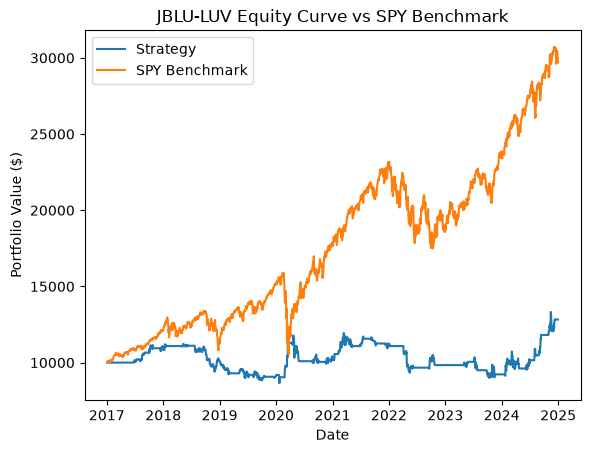

In [12]:
start_date = "2017-01-01"
end_date = "2025-01-01"
benchmark_ticker = "SPY"
spy_returns = bt.benchmark_returns(benchmark_ticker, start_date, end_date)
bt.plot_strategy_vs_benchmark(capital, daily_pnl_cumsum, first_pair, benchmark_ticker, spy_returns, True)

## Correlation to Market Benchmark (SPY)

Despite underperforming SPY on raw return, our strategy's daily returns show almost no correlation with SPY (~-0.01). This supports the core premise of pairs trading as a market-neutral strategy — its performance is driven by the pair's relative mean-reversion rather than broader market direction, making it potentially valuable as a diversification tool rather than a standalone return-maximizing strategy.

In [13]:
strategy_returns = daily_pnl_cumsum.diff() / capital
spy_returns = spy_returns.squeeze() 
correlation = strategy_returns.corr(spy_returns)
print(correlation)

-0.010764334106872298
